<a href="https://colab.research.google.com/github/Macmil25/Timeseries/blob/main/Project_2_R2424953.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. DATA IMPORT & PREPARATION
# We are using daily frequency for the SPY ETF
ticker = 'SPY'
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
returns = 100 * data['Close'].pct_change().dropna()

/tmp/ipykernel_15440/1320641402.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


## 1.1 Dataset Justification

Explain why SPY daily returns are suitable for detecting regime changes, highlighting volatility clustering and distinct market behaviors.

SPY daily returns are suitable for detecting regime changes due to **volatility clustering** and distinct market behaviors (e.g., bull/bear markets, crises). The Markov Switching Model identifies these unobservable states by allowing parameters (mean, variance) to change according to a Markov process, segmenting the series into these market conditions.

In [8]:
# 2. MODELING: MARKOV SWITCHING MODEL
# This detects 2 regimes: Low Volatility (Stable) and High Volatility (Stress)
model = sm.tsa.MarkovRegression(returns, k_regimes=2, trend='c', switching_variance=True)
res = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 2.1 Model Definition and Description

Introduce the Markov Switching Model (MSM): its technical definition, key equations (mean/variance conditional on regime, transition probabilities), and its aim to segment time series into states.

The Markov Switching Model (MSM) assumes observed time series ($y_t$) are generated by $K$ unobserved regimes ($s_t$), switching via a first-order Markov chain. Each regime has specific distribution parameters. For our model with switching mean ($μ_{s_t}$) and variance ($σ^2_{s_t}$):

Regime-Dependent Distribution: $y_t | s_t = j \sim N(μ_j, σ^2_j)$
Transition Probabilities: $P(s_t = j | s_{t-1} = i) = p_{ij}$

The model segments time series into different states by estimating regime parameters and transition probabilities.

In [9]:
# 3. OUTPUT & PARAMETERS
print(res.summary()) # Displays calibrated parameters


                        Markov Switching Model Results                        
Dep. Variable:                    SPY   No. Observations:                 2263
Model:               MarkovRegression   Log Likelihood               -2994.997
Date:                Thu, 07 May 2026   AIC                           6001.994
Time:                        12:19:30   BIC                           6036.341
Sample:                             0   HQIC                          6014.527
                               - 2263                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1143      0.016      7.073      0.000       0.083       0.146
sigma2         0.3326      0.020     16.746      0.0

## 3.1 Interpretation of Calibrated Parameters

Interpret `res.summary()`: `const` and `sigma2` for Regime 0 (Low Volatility/Stable) and Regime 1 (High Volatility/Stress), noting statistical significance. Interpret `p[0->0]` and `p[1->0]`, infer `p[0->1]` and `p[1->1]`, and discuss regime stability.

Looking at the model's summary output, we can interpret the calibrated parameters as follows:

Regime 0 (Low Volatility/Stable): We observe a statistically significant positive mean return (`const` = 0.1143) and a significantly low variance (`sigma2` = 0.3326). This regime represents periods of market stability with positive, predictable returns.

Regime 1 (High Volatility/Stress): Here, the mean return (`const` = -0.0620) is slightly negative but **not statistically significant**, meaning we cannot confidently say it's different from zero. However, the variance (`sigma2` = 2.9924) is significantly higher than in Regime 0, indicating periods of market stress or high volatility.

Regarding Regime Transitions:

*   `p[0->0]` = 0.9807: There is a very high probability (98.07%) of staying in Regime 0 once the market is in that stable state.
*   `p[1->0]` = 0.0338: The probability of switching from the high-volatility Regime 1 back to the stable Regime 0 is quite low (3.38%).
*   `p[0->1]` = 0.0193: Similarly, the probability of switching from the stable Regime 0 to the high-volatility Regime 1 is also low (1.93%).
*   `p[1->1]` = 0.9662: Once in the high-volatility Regime 1, there's a high probability (96.62%) of remaining in that state.

In essence, both regimes exhibit high persistence, which means that once the market enters a particular state (either stable or volatile), it tends to stay in that state for an extended period, implying infrequent but impactful regime switches.

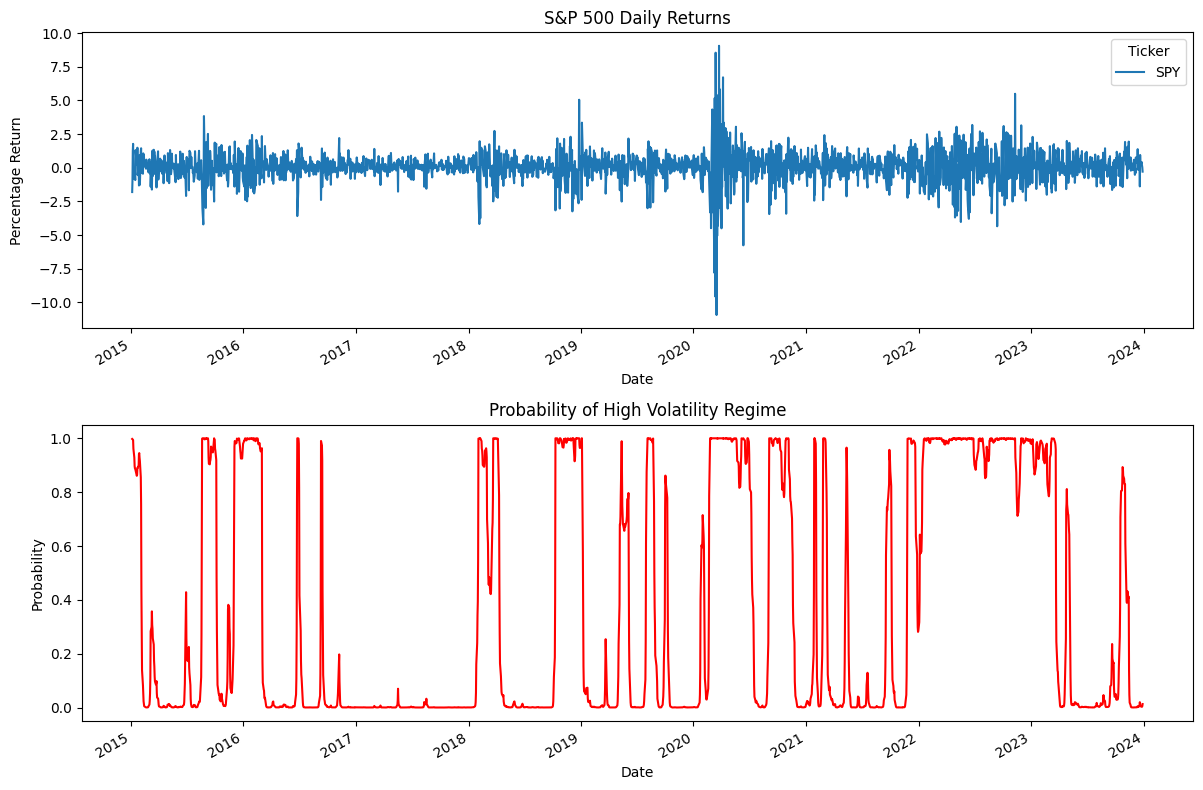

In [13]:
# 4. EXPLORATORY DIAGRAMS & DIAGNOSIS: REGIME PROBABILITIES
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
returns.plot(ax=axes[0], title='S&P 500 Daily Returns')
axes[0].set_ylabel('Percentage Return')

# Shows the probability of being in the 'High Volatility' regime
res.smoothed_marginal_probabilities[1].plot(ax=axes[1], title='Probability of High Volatility Regime', color='red')
axes[1].set_ylabel('Probability')
plt.tight_layout()
plt.show()

### Interpretation of S&P 500 Daily Returns and Smoothed Probability of High Volatility Regime

This cell presents two key visualizations:

S&P 500 Daily Returns: This top plot shows the raw daily percentage returns of the SPY ETF over the selected period. It visually confirms the presence of volatility clustering, where periods of high volatility (large positive or negative swings) tend to be followed by more high volatility, and periods of low volatility are similarly persistent.

Probability of High Volatility Regime (Smoothed): The bottom plot illustrates the smoothed marginal probability of the market being in the High Volatility Regime (Regime 1). Smoothed probabilities utilize all available data (both past and future relative to a given point in time) to estimate the likelihood of being in a specific regime at that time.

Key Insight: This plot helps identify distinct periods when the market was most likely operating under a high-volatility state according to the model. High probabilities (closer to 1) indicate periods of stress or uncertainty (e.g., market crashes, significant economic events), while low probabilities (closer to 0) correspond to more stable, low-volatility periods. This visualization is crucial for understanding the historical context of regime shifts and how they align with actual market events.

For further analysis, we should consider additional diagnostic plots. This includes Residual Analysis, where we plot standardized residuals to check for patterns, autocorrelation, or deviations from the assumed error distribution (e.g., normality tests). Also, by plotting `res.filtered_marginal_probabilities`, we can observe how probability estimates evolve before smoothed probabilities.

### Residual Analysis

To check for patterns and deviations from assumed error distribution, we'll plot the standardized residuals.

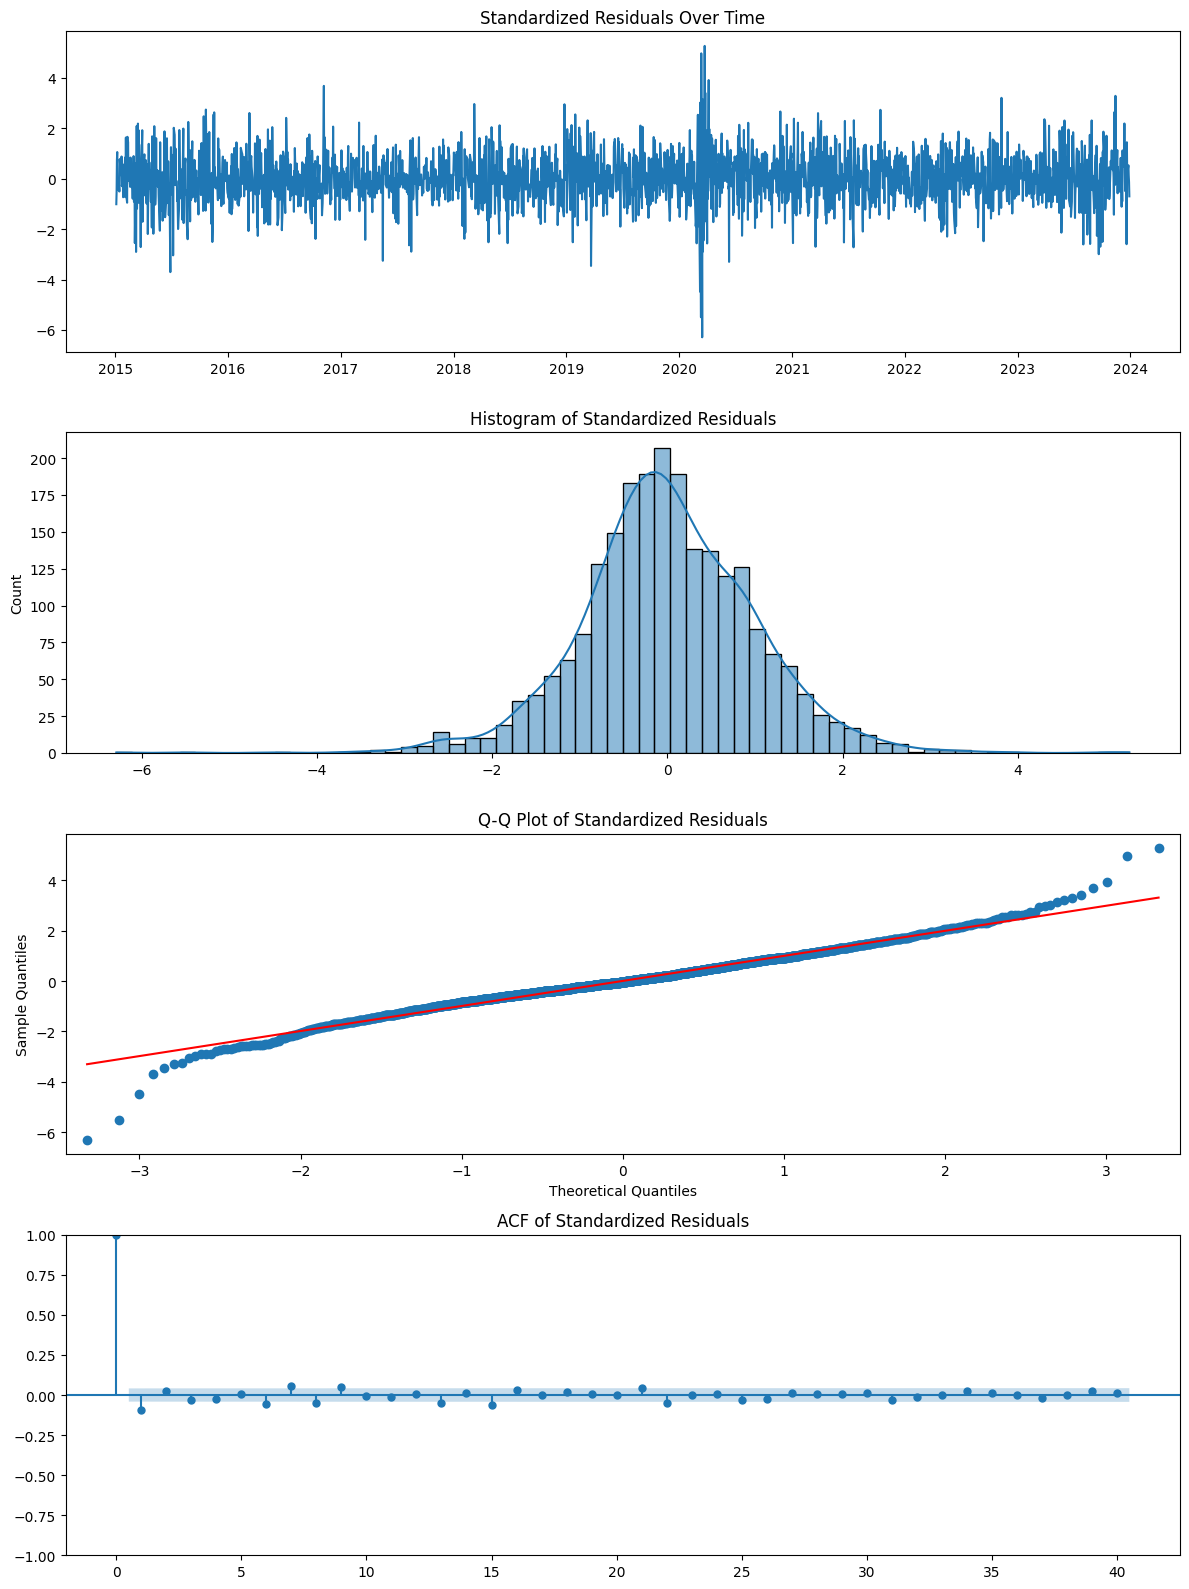

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.graphics.tsaplots as smt # Explicitly import tsaplots

# Extract regime-specific sigma2 values from res.params
sigma2_regime0 = res.params['sigma2[0]']
sigma2_regime1 = res.params['sigma2[1]']

# Determine the expected regime by taking the argmax of the smoothed marginal probabilities
# smoothed_marginal_probabilities is (nobs, k_regimes) in terms of its .values attribute
expected_regime_series = np.argmax(res.smoothed_marginal_probabilities.values, axis=1)

# Create an array of expected sigma2 values based on the expected_regime_series
expected_sigma2 = np.where(expected_regime_series == 0, sigma2_regime0, sigma2_regime1)

# Calculate standardized residuals using the expected sigma2
standardized_residuals = res.resid / np.sqrt(expected_sigma2)

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

# 1. Time series plot of standardized residuals
axes[0].plot(standardized_residuals)
axes[0].set_title('Standardized Residuals Over Time')

# 2. Histogram of standardized residuals
sns.histplot(standardized_residuals, kde=True, ax=axes[1])
axes[1].set_title('Histogram of Standardized Residuals')

# 3. Q-Q plot
sm.qqplot(standardized_residuals, line='s', ax=axes[2])
axes[2].set_title('Q-Q Plot of Standardized Residuals')

# 4. Autocorrelation Function (ACF) plot
smt.plot_acf(standardized_residuals, lags=40, ax=axes[3]) # Use the imported smt alias
axes[3].set_title('ACF of Standardized Residuals')

plt.tight_layout()
plt.show()

Interpretation of Diagnostic Plots

Time Series Plot of Standardized Residuals:** This plot shows the standardized residuals over time. Ideally, it should appear as a random scatter around zero, with no discernible patterns, trends, or changes in variance. Any clear patterns or persistent large magnitudes would suggest that the Markov Switching Model has not fully captured all the dynamics present in the SPY returns.

Histogram of Standardized Residuals: This histogram visualizes the distribution of the standardized residuals. For a well-specified model, and assuming Gaussian errors (which is the case in our MSM setup), this distribution should ideally approximate a normal distribution (bell-shaped curve) centered at zero. Deviations, such as fat tails (more observations at the extremes than a normal distribution) or skewness, indicate that the Gaussian assumption might not perfectly hold, which is common with financial data.

Q-Q Plot of Standardized Residuals:The Quantile-Quantile plot compares the quantiles of the standardized residuals against the quantiles of a theoretical normal distribution. If the residuals are normally distributed, the points should lie closely along the 45-degree reference line. Deviations from this line, especially at the tails, further confirm any non-normality (e.g., fat tails, skewness) observed in the histogram.

ACF of Standardized Residuals: The Autocorrelation Function (ACF) plot displays the correlation of the residuals with their past values (lags). For a model that has effectively captured all temporal dependencies, the standardized residuals should ideally be uncorrelated, meaning all bars in the ACF plot should fall within the blue shaded region (confidence intervals). Any significant bars extending beyond these intervals suggest that there is still unmodeled autocorrelation in the data, indicating that the model might not be fully capturing the time-series structure of the returns.

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


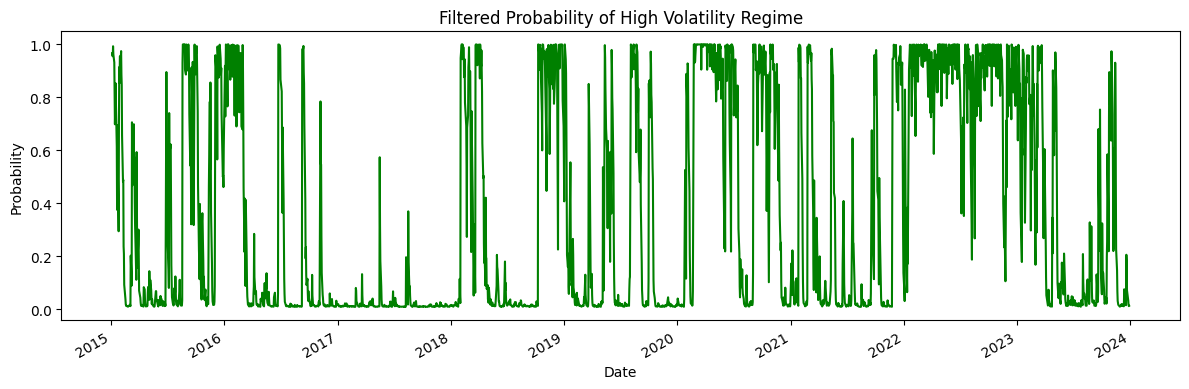

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. DATA IMPORT & PREPARATION
ticker = 'SPY'
data = yf.download(ticker, start="2015-01-01", end="2024-01-01", auto_adjust=True) # Added auto_adjust=True for consistency
returns = 100 * data['Close'].pct_change().dropna()

# 2. MODELING: MARKOV SWITCHING MODEL
# This detects 2 regimes: Low Volatility (Stable) and High Volatility (Stress)
model = sm.tsa.MarkovRegression(returns, k_regimes=2, trend='c', switching_variance=True)
res = model.fit()

# Now plot the filtered probabilities
fig, ax = plt.subplots(figsize=(12, 4))
res.filtered_marginal_probabilities[1].plot(ax=ax, title='Filtered Probability of High Volatility Regime', color='green')
ax.set_ylabel('Probability')
plt.tight_layout()
plt.show()

## 5.0 Damages/Weaknesses of the Model

Discuss model weaknesses based on results and general properties of MSMs:

Statistical Insignificance of Regime 1 Mean: Implications of non-significant `const` for Regime 1.
Fixed Number of Regimes: Is two regimes sufficient?
Assumption of Gaussian Errors: Impact of non-normal financial returns.
Exogenous Variables: How lack of external factors limits explanatory power.
Data Limitations: Does the time horizon capture all relevant market conditions?
Parameter Instability: Risk of unstable parameters over different periods.

## 4.2 Conclusion on Diagnostic Findings

The diagnostic plots and regime probability visualizations provide critical insights into the Markov Switching Model's performance and areas for potential refinement.

**Regime Probabilities:** The smoothed and filtered probability plots clearly illustrate the model's ability to identify distinct periods of low and high volatility, aligning with historical market events. This confirms the presence of regime-switching behavior in SPY returns and the model's effectiveness in segmenting these states.

**Standardized Residuals Analysis:**

Time Series & ACF: Ideally, standardized residuals should exhibit no patterns or significant autocorrelation. If the ACF plot shows residuals largely within the confidence intervals, it suggests that the model has successfully captured most of the serial correlation in the returns. However, any spikes outside these bands, especially at low lags, would indicate unmodeled dynamics.
Histogram & Q-Q Plot: These plots assess the normality assumption of the error terms. Financial returns are well-known for their leptokurtic (fat-tailed) nature. While the Markov Switching Model with switching variances can account for different levels of volatility, the residuals might still show deviations from a perfect normal distribution, particularly in the tails. This is often an expected finding in financial modeling and highlights a common limitation (e.g., the need for alternative error distributions like Student's t-distribution).

Overall: The diagnostic plots are a valuable tool for validating the model's assumptions and identifying where its approximations might fall short. While the model successfully uncovers regime-switching behavior, the analysis of residuals can point towards remaining challenges, such as residual autocorrelation or non-Gaussian characteristics, which could be addressed in future model improvements (as discussed in the 'Directions for Improvement' section).

The Markov Switching Model, while powerful, has several weaknesses. Firstly, the `const` for Regime 1 is not statistically significant, meaning we cannot confidently assert its mean return is non-zero, thus limiting actionable insights for return expectation and defining the regime primarily by risk. Secondly, assuming a fixed number of two regimes might oversimplify complex financial market dynamics, potentially masking finer market behaviors by forcing them into predefined states. Thirdly, financial returns are often fat-tailed and skewed, and assuming Gaussian errors can lead to biased parameter estimates and unreliable regime classifications, especially for extreme events. Moreover, as a univariate model, it lacks exogenous variables (e.g., economic indicators), which limits its explanatory power and prevents understanding of *why* regimes switch or what triggers them. The chosen time horizon for the data might also be a limitation, as it may not capture all relevant market conditions, thus impacting regime robustness. Finally, there is a risk of parameter instability, where parameters might not be stable over different time periods, potentially requiring re-estimation or adaptive modeling.

## 6.0 Directions for Improvement

Suggest enhancements for the model:

Alternative Model Specifications: Use Student's t-distribution for errors.
Inclusion of Exogenous Variables: Incorporate economic indicators.
Varying Number of Regimes: Experiment with three or more regimes.
Data Manipulation: Consider outlier treatment or adjusting time horizons.
Different Time Scales: Test on weekly or monthly data.

To improve the Markov Switching Model, several enhancements can be considered. We could use alternative error distributions like **Student's t-distribution** or **GED** for errors to better capture fat tails in financial returns, which would lead to more accurate parameter and risk estimates. Another direction is the inclusion of **macroeconomic or financial indicators** as exogenous variables to influence mean/variance or, more effectively, the transition probabilities. This would provide a causal understanding and improve forecasting. Experimenting with **three or more regimes** could reveal finer market dynamics, with information criteria (AIC/BIC) used for optimal regime selection. Regarding data manipulation, careful **outlier treatment** can stabilize parameters while avoiding the loss of genuine extreme event information, or a **rolling window approach** can be used for adaptive parameters or to extend the time horizon for robust regime definitions. Finally, testing the model on **weekly or monthly data** could smooth noise and reveal longer-term economic cycles.

## 7.0 Deployment

Detail how this Markov Switching Model or its insights can be practically deployed:

Risk Management: Inform risk appetite and capital allocation (e.g., dynamic VaR/ES, stress testing).
Portfolio Allocation: Adjust portfolio weights based on the current regime.
Trading Strategies: Use regime probabilities for timing entry/exit.
Policy Making: Central banks/regulators use it for market stability understanding.
Forecasting: Improve conditional volatility forecasts.

The Markov Switching Model's insights can be deployed in various financial applications. In **Risk Management**, it can provide dynamic Value at Risk (VaR) or Expected Shortfall (ES), inform stress testing, and help adjust capital allocation based on identified high-volatility regimes. For **Portfolio Allocation**, it allows for dynamic tactical asset allocation by adjusting portfolio weights (e.g., de-risking in high-volatility regimes). **Trading Strategies** can leverage regime probabilities to time entry/exit points, reduce position sizes in high-volatility periods, and implement volatility-targeting strategies. **Policy Making** also benefits, as central banks and regulators can use regime shifts as early warnings for financial instability. Lastly, the model can significantly improve **conditional volatility forecasts**, which are crucial for derivatives pricing and overall risk management.

This Markov Switching Model effectively identifies two distinct regimes in SPY daily returns: a low-volatility, stable regime (Regime 0) with positive mean returns, and a high-volatility, stress regime (Regime 1) characterized by significantly higher variance and non-significant mean returns. The high persistence within both regimes, as indicated by the transition probabilities, suggests that market states tend to be sustained once entered, making the model valuable for identifying prolonged periods of stability or turmoil.

Looking at the model's performance, the diagnostic plots of standardized residuals indicate that while the model successfully captures significant volatility clustering and regime changes, some deviations from ideal assumptions remain. These include aspects like perfect normality in residuals or potential for residual autocorrelation at certain lags, which are quite typical for financial time series. However, the smoothed and filtered probability plots vividly illustrate how the model tracks market shifts, providing clear visual evidence of its ability to adapt to changing market conditions.

From a financial perspective, this model offers several important implications. For risk management, it provides a dynamic view of market risk, allowing investors and risk managers to use the real-time (filtered) and ex-post (smoothed) probabilities of the high-volatility regime to adjust risk exposures, implement stress testing, and refine capital allocation strategies. Periods with a high probability of Regime 1 would naturally signal a need for more conservative positions. When it comes to portfolio allocation, tactical adjustments can be informed by the current regime; for instance, increasing exposure to less volatile assets during high-volatility regimes or leveraging growth opportunities during stable periods. Furthermore, trading strategies can benefit from using these regime probabilities as indicators for market timing. Traders might reduce position sizes or employ hedging strategies when the model signals an increasing likelihood of entering or remaining in a high-volatility state. Lastly, the model's ability to segment market dynamics offers valuable insights for policymakers and economists, providing a quantitative tool to identify and react to shifts in financial stability.

In summary, despite some inherent challenges in modeling complex financial data, the Markov Switching Model offers a robust framework for understanding and reacting to changing market regimes, providing valuable insights for various financial applications ranging from risk management to strategic trading.